In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'D:\car-price-prediction\data\Car details v3.csv')
print(df.shape)
df.head()

(8128, 13)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [5]:
df.dropna(inplace=True)
df['engine'] = df['engine'].str.extract(r'(\d+)').astype(float)
df['max_power'] = df['max_power'].str.extract(r'(\d+\.?\d*)').astype(float)
df.rename(columns={'engine':'engine_cc','max_power':'max_power_bhp'}, inplace=True)
df['car_age'] = 2024 - df['year']
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine_cc,max_power_bhp,torque,seats,car_age
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248.0,74.00,190Nm@ 2000rpm,5.0,10
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498.0,103.52,250Nm@ 1500-2500rpm,5.0,10
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497.0,78.00,"12.7@ 2,700(kgm@ rpm)",5.0,18
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396.0,90.00,22.4 kgm at 1750-2750rpm,5.0,14
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298.0,88.20,"11.5@ 4,500(kgm@ rpm)",5.0,17


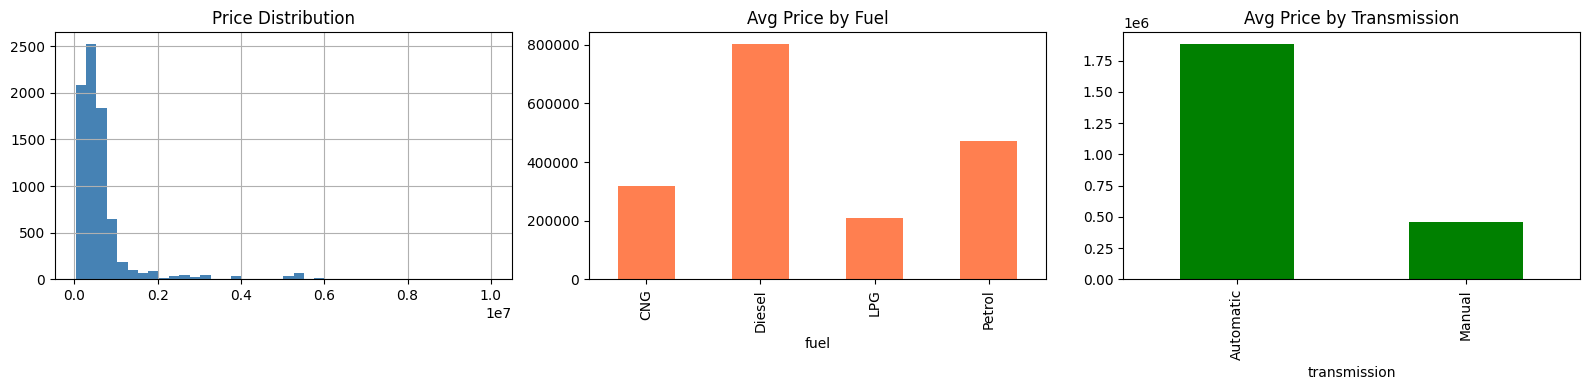

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
df['selling_price'].hist(bins=40, ax=axes[0], color='steelblue')
axes[0].set_title('Price Distribution')
df.groupby('fuel')['selling_price'].mean().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Avg Price by Fuel')
df.groupby('transmission')['selling_price'].mean().plot(kind='bar', ax=axes[2], color='green')
axes[2].set_title('Avg Price by Transmission')
plt.tight_layout()
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

num_cols = ['year', 'km_driven', 'engine_cc', 'max_power_bhp', 'seats', 'car_age']
cat_cols = ['fuel', 'seller_type', 'transmission', 'owner']

X = df[num_cols + cat_cols]
y = df['selling_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
], remainder='passthrough')

model = Pipeline([
    ('pre', preprocessor),
    ('clf', GradientBoostingRegressor(n_estimators=200, max_depth=5, random_state=42))
])

model.fit(X_train, y_train)
preds = model.predict(X_test)

print(f"R² Score : {r2_score(y_test, preds):.4f}")
print(f"MAE      : ₹{mean_absolute_error(y_test, preds):,.0f}")

R² Score : 0.9830
MAE      : ₹67,245


In [8]:
import pandas as pd

new_car = pd.DataFrame([{
    'year': 2019, 'km_driven': 45000,
    'fuel': 'Petrol', 'seller_type': 'Individual',
    'transmission': 'Manual', 'owner': 'First Owner',
    'engine_cc': 1197, 'max_power_bhp': 82.0,
    'seats': 5, 'car_age': 5
}])

predicted_price = model.predict(new_car)[0]
print(f"Predicted Price: ₹{predicted_price:,.0f}  (₹{predicted_price/1e5:.2f} Lakhs)")

Predicted Price: ₹575,495  (₹5.75 Lakhs)


In [9]:
import json

# Real stats from your trained model
stats = {
    "total_listings": len(df),
    "avg_price": round(df['selling_price'].mean()),
    "r2": round(r2_score(y_test, preds), 4),
    "mae": round(mean_absolute_error(y_test, preds)),
    "avg_by_fuel": df.groupby('fuel')['selling_price'].mean().round().to_dict(),
    "avg_by_transmission": df.groupby('transmission')['selling_price'].mean().round().to_dict(),
    "avg_by_owner": df.groupby('owner')['selling_price'].mean().round().to_dict(),
    "avg_by_year": df.groupby('year')['selling_price'].mean().round().to_dict(),
    "fuel_counts": df['fuel'].value_counts().to_dict(),
    "sample_rows": df[['year','km_driven','fuel','transmission','owner',
                        'engine_cc','max_power_bhp','seats','selling_price']]
                        .head(20).to_dict(orient='records')
}

with open('dashboard/data.json', 'w') as f:
    json.dump(stats, f, indent=2)

print("✅ data.json exported!")

✅ data.json exported!
